# I'll make VAE model for urban mobility. Let's go

In [1]:
import pandas as pd
import numpy as np
import ast
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
from tqdm import tqdm

## Read Data

In [2]:
df = pd.read_csv('../Data/train_wd_hc.csv', index_col = 0)

df.reset_index(drop=True, inplace = True)
df.drop(columns = ['id'], inplace= True)

df_x = df[['transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix']]
df_y = df[['pattern', 'max_ride', 'min_ride']]

df_x = df_x.apply(lambda col: col.fillna(col.min()), axis=0)

# Parse pattern strings to lists and denormalize
def denormalize_pattern(pattern_str, min_ride, max_ride):
    # Convert string representation to list
    pattern_list = ast.literal_eval(pattern_str)
    # Denormalize: value * (max_ride - min_ride) + min_ride
    denormalized = [val * (max_ride - min_ride) + min_ride for val in pattern_list]
    return np.array(denormalized)

# Apply to each row
df_y['ridership'] = df_y.apply(
    lambda row: denormalize_pattern(row['pattern'], row['min_ride'], row['max_ride']),
    axis=1
)

# Get English name
df_enname = pd.read_csv('../Data/서울교통공사_역명다국어표기_20241101.csv', encoding = 'cp949')
df_enname['한글'] = df_enname['한글'].apply(lambda x: x.split('(')[0])
df_enname.drop_duplicates(subset=['한글'], inplace=True)
df_enname.rename(columns={'한글':'name', '영문':'en_name'}, inplace=True)
df = df.merge(df_enname[['name', 'en_name']], on = 'name', how='left', suffixes=('', '_y'))

df.loc[df['name'] == '미아사거리', 'en_name'] = 'MiaSageori'
df.loc[df['name'] == '뚝섬유원지', 'en_name'] = 'DduksomPark'
df.loc[df['name'] == '화랑대', 'en_name'] = 'Hwarangdae'
df.loc[df['name'] == '서울', 'en_name'] = 'SeoulStation'

df = df[['name', 'en_name', 'transfer', 'outer', 'terminal', 'cbd', 'tfa_r', 'tfa_c',
       'tfa_w', 'univ', 'pop', 'job', 'bus', 'buld_sum', 'rest', 'green',
       'tfa_n', 'tfa_f', 'lumix', 'index', 'weekend', 'hacha', 'max_ride',
       'min_ride', 'pattern', 'cA', 'cD']]
df[df['en_name'].isna()]

train_id = list(df[~df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)
test_id = list(df[df['name'].isin(['태릉입구', '상봉', '상도', '강남', '시청', '공덕'])].index)

train_data_x = df_x.iloc[train_id]
train_data_y = df_y['ridership'].iloc[train_id]

test_data_x = df_x.iloc[test_id]
test_data_y = df_y['ridership'].iloc[test_id]

train_input = train_data_x
train_output = train_data_y
val_input = test_data_x
val_output = test_data_y    

x_stacks, y_stacks = [], []

for k, row in train_input.iterrows():
    # repeat df_x row for 20 time steps and stack with one-hot time vectors and ridership
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(train_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals) # avoid log(0)
    temp_stack = np.hstack([time_onehots, x_rep])
    x_stacks.append(temp_stack)
    y_stacks.append(ridership_vals)

train_x, train_y = np.vstack(x_stacks), np.vstack(y_stacks)

x_train_tensor = torch.tensor(train_x, dtype=torch.float)
y_train_tensor = torch.tensor(np.log(train_y), dtype=torch.float)


C:\Users\id310624\AppData\Local\Temp\ipykernel_9208\2352029817.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_y['ridership'] = df_y.apply(


## Model definition

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=17, latent_dim=8, output_dim=20):
        super(VAE, self).__init__()
        
        # --- Encoder: 17 -> Latent Space ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 10),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(10, latent_dim)
        self.fc_logvar = nn.Linear(10, latent_dim)
        
        # --- Decoder: Latent Space -> 20 ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10),
            nn.ReLU(),
            nn.Linear(10, output_dim) # Final output dimension set to 20
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        
        # Sample
        z = self.reparameterize(mu, logvar)
        
        # Decode
        return self.decoder(z), mu, logvar

# --- Loss Function ---
def loss_function(recon_y, y_target, mu, logvar):
    # MSE for reconstruction (comparing output to the 20-dim target)
    recon_loss = F.mse_loss(recon_y, y_target, reduction='sum')
    
    # KL Divergence
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kld_loss

## Training

In [ ]:

# 1. Prepare your Paired Dataset
class MobilityDataset(Dataset):
    def __init__(self, x_data, y_labels):
        # x_data shape: [N, 17], y_labels shape: [N, 20]
        self.x = torch.tensor(x_data, dtype=torch.float32)
        self.y = torch.tensor(y_labels, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


In [39]:
from torch.utils.data import TensorDataset, DataLoader

# 1. Setup Data
# Assuming train_x.shape is [N, 17] and train_y.shape is [N, 20]
dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# 2. Initialize Model & Optimizer
model = VAE(input_dim=37, latent_dim= 6, output_dim=20)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3. Training Loop
num_epochs = 250
beta = 0  # Adjust this to balance prediction accuracy vs. latent space smoothness

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        
        # Forward Pass
        # batch_x (17 dims) -> y_hat (20 dims)
        y_hat, mu, logvar = model(batch_x)
        
        # Calculate Loss
        # We compare the 20-dim output (y_hat) to 20-dim ground truth (batch_y)
        recon_loss = F.mse_loss(y_hat, batch_y, reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        loss = recon_loss + (beta * kld_loss)
        
        # Backward Pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Avg Loss: {train_loss/len(train_x):.4f}")

C:\Users\id310624\AppData\Local\Temp\ipykernel_9208\1737642685.py:29: UserWarning: Using a target size (torch.Size([64, 1])) that is different to the input size (torch.Size([64, 20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(y_hat, batch_y, reduction='sum')
C:\Users\id310624\AppData\Local\Temp\ipykernel_9208\1737642685.py:29: UserWarning: Using a target size (torch.Size([48, 1])) that is different to the input size (torch.Size([48, 20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(y_hat, batch_y, reduction='sum')


Epoch 10/250 | Avg Loss: 10.0695
Epoch 20/250 | Avg Loss: 7.3010
Epoch 30/250 | Avg Loss: 6.2308
Epoch 40/250 | Avg Loss: 5.4185
Epoch 50/250 | Avg Loss: 4.8050
Epoch 60/250 | Avg Loss: 4.3469
Epoch 70/250 | Avg Loss: 4.0278
Epoch 80/250 | Avg Loss: 3.7921
Epoch 90/250 | Avg Loss: 3.5657
Epoch 100/250 | Avg Loss: 3.2907
Epoch 110/250 | Avg Loss: 3.1295
Epoch 120/250 | Avg Loss: 2.9059
Epoch 130/250 | Avg Loss: 2.8038
Epoch 140/250 | Avg Loss: 2.6681
Epoch 150/250 | Avg Loss: 2.5296
Epoch 160/250 | Avg Loss: 2.4662
Epoch 170/250 | Avg Loss: 2.4669
Epoch 180/250 | Avg Loss: 2.3518
Epoch 190/250 | Avg Loss: 2.3062
Epoch 200/250 | Avg Loss: 2.2334
Epoch 210/250 | Avg Loss: 2.2271
Epoch 220/250 | Avg Loss: 2.1344
Epoch 230/250 | Avg Loss: 2.0971
Epoch 240/250 | Avg Loss: 2.0988
Epoch 250/250 | Avg Loss: 2.0374


## Evaluation

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

torch.Size([20, 20])


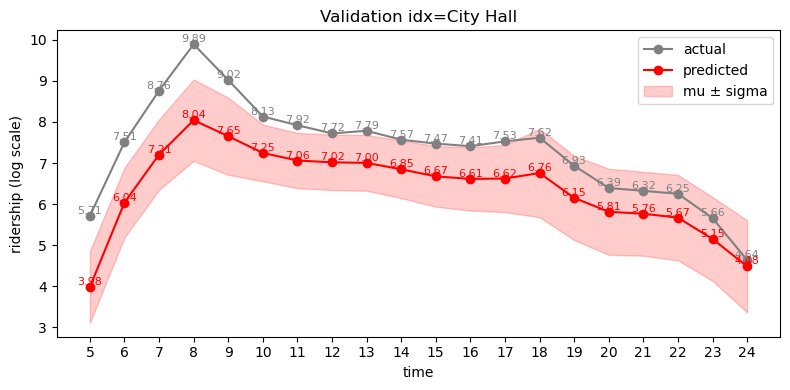

Validation:  17%|█▋        | 1/6 [00:00<00:02,  2.33it/s]

torch.Size([20, 20])


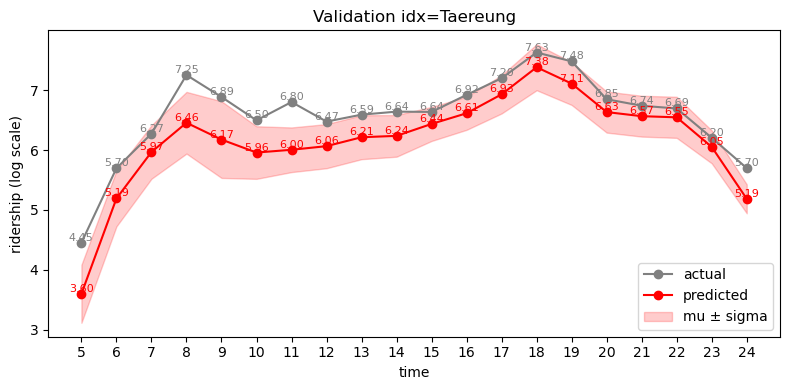

Validation:  33%|███▎      | 2/6 [00:00<00:01,  2.37it/s]

torch.Size([20, 20])


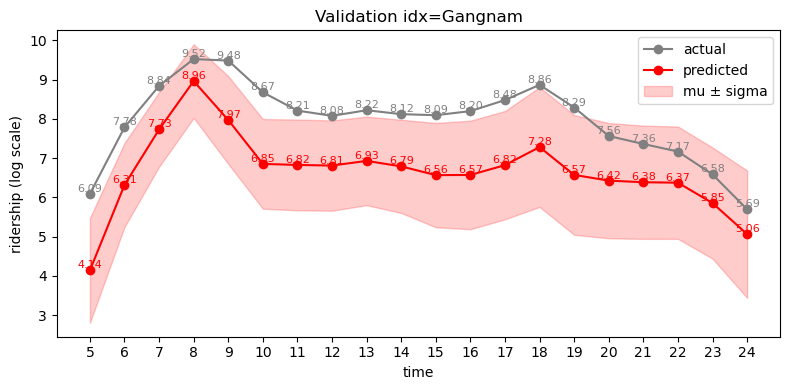

Validation:  50%|█████     | 3/6 [00:01<00:01,  2.48it/s]

torch.Size([20, 20])


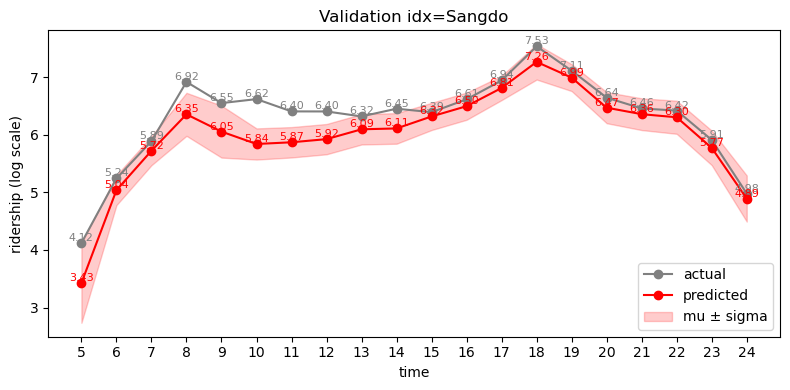

Validation:  67%|██████▋   | 4/6 [00:01<00:00,  2.58it/s]

torch.Size([20, 20])


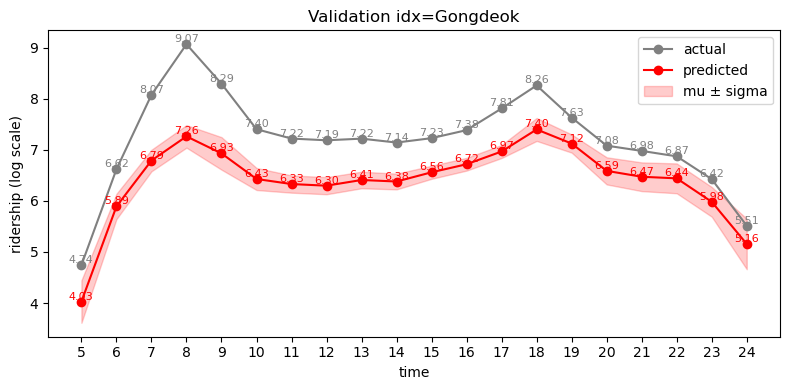

Validation:  83%|████████▎ | 5/6 [00:01<00:00,  2.58it/s]

torch.Size([20, 20])


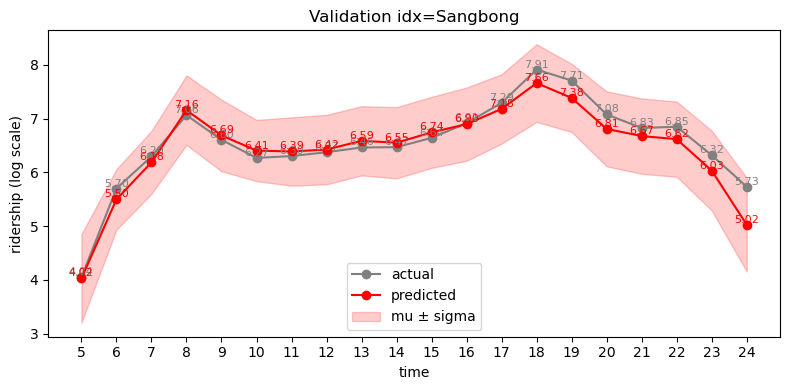

Validation: 100%|██████████| 6/6 [00:02<00:00,  2.51it/s]

Mean Absolute Error: 78.073256


In [ ]:
model.eval()

mse = 0

for k, row in tqdm(val_input.iterrows(), total=len(val_input), desc="Validation"):
    # repeat df_x row for 20 time steps and stack with one-hot time vectors
    x_rep = np.tile(row.values.reshape(1, -1), (20, 1))
    time_onehots = np.eye(20)
    ridership_vals = np.array(val_output.loc[k]).reshape(-1, 1)
    ridership_vals = np.where(ridership_vals == 0, 1, ridership_vals)
    temp_stack = np.hstack([time_onehots, x_rep])
    
    # Make predictions using the linear regression model

    inputs = temp_stack
    inputs_tensor = torch.tensor(inputs, dtype=torch.float)
    if k == 0: print(inputs_tensor)

    with torch.no_grad():
        # Use the mean (mu) directly for a deterministic prediction
        h = model.encoder(inputs_tensor)
        mu = model.fc_mu(h)
        prediction = model.decoder(mu)

    preds = prediction.mean(axis = 1).detach().cpu().numpy().flatten()
    preds_sigma = prediction.std(axis = 1).detach().cpu().numpy().flatten()
    ridership_flat = np.log(ridership_vals).flatten()

    
    # record results and update mse
    mse += np.sum(np.abs(preds.flatten() - ridership_flat))
    
    # plot actual (grey) vs predicted (red)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(ridership_flat)), ridership_flat, color='grey', marker='o', label='actual')
    plt.plot(range(len(preds)), preds, color='red', marker='o', label='predicted')
    plt.fill_between(range(len(preds)), preds - preds_sigma*100, preds + preds_sigma*100, color='red', alpha=0.2, label='mu ± sigma')
    
    # station name
    st_name = df.loc[k]['en_name']


    for t in range(len(ridership_flat)):
        plt.text(t, float(ridership_flat[t]), f"{float(ridership_flat[t]):.2f}", color='grey', ha='center', va='bottom', fontsize=8)
        plt.text(t, float(preds[t]), f"{float(preds[t]):.2f}", color='red', ha='center', va='bottom', fontsize=8)
        plt.xlabel('time')
    plt.ylabel('ridership (log scale)')
    plt.xticks(range(len(ridership_flat)), range(5, 25))
    plt.title(f'Validation idx={st_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

print(f"Mean Absolute Error: {mse:.6f}")




In [9]:
print(ridership_vals.shape)

(20, 1)


In [ ]:
ridership_flat.size

In [ ]:
model = VAE(input_dim=17, latent_dim=8, output_dim=20)
example_input = torch.randn(1, 17) # Batch size of 1
output, mu, logvar = model(example_input)

print(f"Output shape: {output.shape}") # Should be [1, 20]